<b><h1><center>Series and DataFrame Methods</center></h1></b>

<br>

In [1]:
# importing libraries
import numpy as np
import pandas as pd

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# loading datasets
movies = pd.read_csv("data/18_data/movies.csv")
ipl = pd.read_csv("data/18_data/ipl-matches.csv")
batsman = pd.read_csv("data/18_data/batsman_runs_ipl.csv")

<br>

# **astype()**
The astype() method is used to convert the data type (dtype) of a Series or DataFrame.

**Think of it as saying:**

"I don't want this data type anymore. Convert it into another one."


### **Parameter 1:** `dtype`
- It specifies which data type you want to convert to.
- dtype=(anyseries or dataframe)

### **Parameter 2:** `copy`
- This tells Pandas whether to create a new object.
- copy=True/False

### **Parameter 3:** `errors`
- This tells Pandas if conversion fail what to do.
- errors=('ignore'/'raise')
- ignore will leave the datatype of series or dataframe as it is without raising error while raise give error.

<br>

### **astype with Series**

In [267]:
s = pd.Series([1, 2, 3, 4, 5, 6])
s.astype(float)

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
dtype: float64

In [270]:
# if conversion fail then it give error thats means that by default the errors parameter is raise as errors='raise'
s = pd.Series([2, 3, 4, 5, "salman"])
s.astype(float)      

ValueError: could not convert string to float: 'salman'

In [271]:
# in order to ignore the error we use error=ignore

s.astype(float, errors="ignore")

0         2
1         3
2         4
3         5
4    salman
dtype: object

<br>

### **astype with DataFrame**

In [272]:
movies.head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [273]:
movies.dtypes

title_x                 str
imdb_id                 str
poster_path             str
wiki_link               str
title_y                 str
original_title          str
is_adult              int64
year_of_release       int64
runtime                 str
genres                  str
imdb_rating         float64
imdb_votes            int64
story                   str
summary                 str
tagline                 str
actors                  str
wins_nominations        str
release_date            str
dtype: object

In [274]:
movies.astype('object').dtypes    # it will convert all the columns to object

title_x             object
imdb_id             object
poster_path         object
wiki_link           object
title_y             object
original_title      object
is_adult            object
year_of_release     object
runtime             object
genres              object
imdb_rating         object
imdb_votes          object
story               object
summary             object
tagline             object
actors              object
wins_nominations    object
release_date        object
dtype: object

In [275]:
movies.astype('int16', errors='ignore').dtypes          # it will convert the datatypes of all columns to int16 if possible if fail then just ignore that without throwing error

title_x               str
imdb_id               str
poster_path           str
wiki_link             str
title_y               str
original_title        str
is_adult            int16
year_of_release     int16
runtime               str
genres                str
imdb_rating         int16
imdb_votes          int16
story                 str
summary               str
tagline               str
actors                str
wins_nominations      str
release_date          str
dtype: object

In [276]:
# it will change the data types of dataframe according to provided dictionary
movies.astype({
    "title_x":'object', 
    'year_of_release':'category',
    'genres':'category'
    
}).dtypes

title_x               object
imdb_id                  str
poster_path              str
wiki_link                str
title_y                  str
original_title           str
is_adult               int64
year_of_release     category
runtime                  str
genres              category
imdb_rating          float64
imdb_votes             int64
story                    str
summary                  str
tagline                  str
actors                   str
wins_nominations         str
release_date             str
dtype: object

### **If a dataframe has null values**
If a dataframe or series have null values then we can convert the datatype of dataframe or series only to float because pandas consider null values as float and in this way pandas can also convert null into float.

In [277]:
d = pd.DataFrame(np.array([
    [3, 4, 5],
    [3, np.nan, 5],
    [6, 7, 3], 
    [np.nan, 5, np.nan]
]), columns=["math", "bio","urdu"])

d["math"].astype(int)          # it cannot change to integer because of null values

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [278]:
d["math"].astype('float64')      # but it change to float instead of null values and pandas consider null values as a float

0    3.0
1    3.0
2    6.0
3    NaN
Name: math, dtype: float64

<br>

# **to_numeric()**
This method is actully used to convert any datatype series to numeric(float).

This is just like astype but it solve one of the most big problem of astype which is following.

- When we use astype for converion of datatype and if the conversion fail then it will ignore the conversion or simply raise an error as `errors=ignore/raise` 
- But when we use to_numeric and the conversion fail then we have two ways either by force convert the datatype of those values which is possible to convert to float and remaining valuse become null or raise an error. `errors=raise/coerce` here the coerce will by force convert all the values which can convert to float and remaining become null.
- note this is only used with series

### **to_numeric with Series**

In [279]:
# see the below when i want to convert any str series then it give error as errors by defualt is raise
pd.to_numeric(movies["title_x"])

ValueError: Unable to parse string "Uri: The Surgical Strike" at position 0

In [280]:
# look at this as i used errors=coerce which wiill convert the posible values by force and return null in place where the conversion not possilble
pd.to_numeric(movies["title_x"], errors='coerce')

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
1624   NaN
1625   NaN
1626   NaN
1627   NaN
1628   NaN
Name: title_x, Length: 1629, dtype: float64

In [281]:
s = pd.Series([3, 4, 5, 6, 'salma'])

pd.to_numeric(s, errors='coerce') # look at this result as 'salma' is not possible to convert to float so it become NaN

0    3.0
1    4.0
2    5.0
3    6.0
4    NaN
dtype: float64

<br>

<br>

# **value_counts()**
The value_counts() method counts how many times each unique value appears in a Series or DataFrame column.

**Think of it as asking:**

"How many times does each value occur?"


### **Parameters**

| Parameter   | Default | Purpose                                           |
| ----------- | ------- | ------------------------------------------------- |
| `normalize` | `False` | Return proportions instead of counts              |
| `sort`      | `True`  | Sort by frequency                                 |
| `ascending` | `False` | Sort from smallest to largest count               |
| `bins`      | `None`  | Group numeric values into intervals (Series only) |
| `dropna`    | `True`  | Exclude missing values                            |
| `subset`    | `None`  | Columns to consider (DataFrame only)              |


### **value_counts with Series**


Series.value_counts(
    normalize=False,
    sort=True,
    ascending=False,
    bins=None,
    dropna=True
)

In [282]:
s = pd.Series(["salman", "ubaid", "junaid", "salman", "ubaid", "naveed", "junaid", np.nan, "salman", "farhad", "waseem", "nadeem", np.nan])

s.value_counts()                 # by defualt it count the frequncy of each item

salman    3
ubaid     2
junaid    2
naveed    1
farhad    1
waseem    1
nadeem    1
Name: count, dtype: int64

In [283]:
s.value_counts(normalize=True)     # it divide each value by the total number of values but it will not consider the null values

salman    0.272727
ubaid     0.181818
junaid    0.181818
naveed    0.090909
farhad    0.090909
waseem    0.090909
nadeem    0.090909
Name: proportion, dtype: float64

In [284]:
# actually the normalize internally work like this
 
divisor = s[s.notnull()].shape[0]      # count all non null values 

s.value_counts()/divisor     # internally the normalize did like this 

salman    0.272727
ubaid     0.181818
junaid    0.181818
naveed    0.090909
farhad    0.090909
waseem    0.090909
nadeem    0.090909
Name: count, dtype: float64

In [285]:
s.value_counts(ascending=True)        # by defualt the values are sorted in descending order so we can change its order

naveed    1
farhad    1
waseem    1
nadeem    1
ubaid     2
junaid    2
salman    3
Name: count, dtype: int64

In [286]:
s.value_counts(sort=False, ascending=True)    # if i false the sort and then try to change its order then it will not work because we have false the sort

salman    3
ubaid     2
junaid    2
naveed    1
farhad    1
waseem    1
nadeem    1
Name: count, dtype: int64

In [287]:
# it i want to count the null values then i can do it also by defualt the dropna=True as it drop the null before applying value_counts
s.value_counts(dropna=False)

salman    3
ubaid     2
junaid    2
NaN       2
naveed    1
farhad    1
waseem    1
nadeem    1
Name: count, dtype: int64

In [288]:
# we can also combine value in a group like histogram to count it but only work on numeric data

s = pd.Series([1, 2, 3, 2, 3, 2, 1, 4, 5, 5, 6, 4, 7, 6, 5, 4, 7, 5, 3, 5, 7, 5, 6, 7, 8, 4, 3, 2, 4])

s.value_counts(bins=5)

(3.8, 5.2]      11
(0.992, 2.4]     6
(6.6, 8.0]       5
(2.4, 3.8]       4
(5.2, 6.6]       3
Name: count, dtype: int64

### **value_counts with DataFrame**
DataFrame.value_counts(
    subset=None,
    normalize=False,
    sort=True,
    ascending=False,
    dropna=True
)

In [289]:
s = pd.DataFrame([[1, 2, 3],
                  [3, 2, 4],
                  [6, 4, 5],
                  [1, 2, 3],
                  [5, 4, 6],
                  [5, 4, 6],
                  ], columns=["math", 'eng', 'urdu'])


s.value_counts()  # by applying value_counts() on dataframe it count value having all values same in rows

math  eng  urdu
1     2    3       2
5     4    6       2
3     2    4       1
6     4    5       1
Name: count, dtype: int64

In [290]:
s.value_counts(subset=["math", 'eng'], ascending=True)    # we can provide some columns of dataframe and also use asceding order

math  eng
3     2      1
6     4      1
1     2      2
5     4      2
Name: count, dtype: int64

In [291]:
s["math"].value_counts()   # single columns(series) from dataframe

math
1    2
5    2
3    1
6    1
Name: count, dtype: int64

In [292]:
s["math"].value_counts(ascending=True)         # descending order

math
3    1
6    1
1    2
5    2
Name: count, dtype: int64

In [293]:
s.value_counts(normalize=True)

math  eng  urdu
1     2    3       0.333333
5     4    6       0.333333
3     2    4       0.166667
6     4    5       0.166667
Name: proportion, dtype: float64

In [294]:
s.value_counts(dropna=False)

math  eng  urdu
1     2    3       2
5     4    6       2
3     2    4       1
6     4    5       1
Name: count, dtype: int64

In [295]:
ipl.head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [296]:
ipl[['City', 'Team1']].value_counts()

City        Team1                      
Mumbai      Mumbai Indians                 72
Kolkata     Kolkata Knight Riders          66
Delhi       Delhi Daredevils               62
Bangalore   Royal Challengers Bangalore    60
Chandigarh  Kings XI Punjab                52
                                           ..
Cape Town   Kolkata Knight Riders           1
            Deccan Chargers                 1
            Delhi Daredevils                1
            Chennai Super Kings             1
Mumbai      Delhi Daredevils                1
Name: count, Length: 169, dtype: int64

### **Some Question regarding value_counts**

### **1. Toss decision plot**

<Axes: >

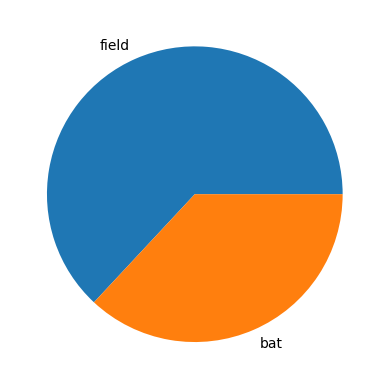

In [297]:
ipl["TossDecision"].value_counts(ascending=False).plot(kind="pie")

### **2. how many matches each team has played**

<Axes: xlabel='Team1'>

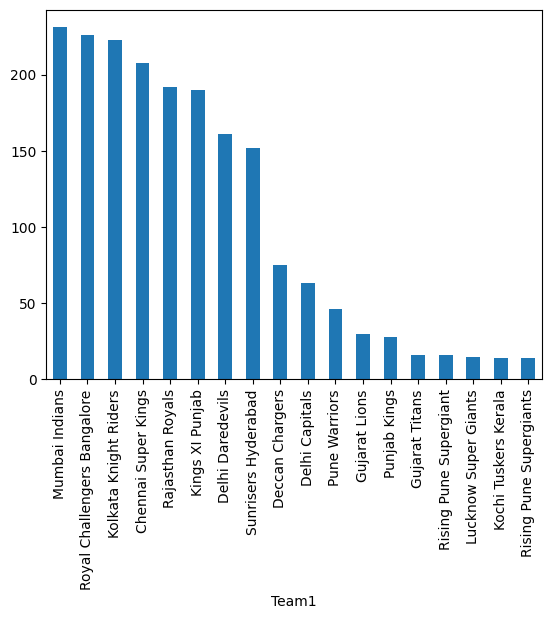

In [298]:
# sort_values is used to sort the values in ascending order or descending order
(ipl["Team1"].value_counts(ascending=False)+ipl["Team2"].value_counts(ascending=False)).sort_values(ascending=False).plot(kind="bar")

<br>

# **sort_values()**
The sort_values() method is used to sort data based on the actual values in a Series or one or more DataFrame columns.

**Think of it as asking:**

"Arrange my data from smallest to largest (or largest to smallest)."

### **Parameters**

| Parameter      | Series |  DataFrame | Purpose                                                            |
| -------------- | :----: | :--------: | ------------------------------------------------------------------ |
| `by`           |    ❌   | ✅ Required | Column(s) to sort by                                               |
| `axis`         |    ✅   |      ✅     | Sort rows (`0`) or columns (`1`)                                   |
| `ascending`    |    ✅   |      ✅     | Ascending or descending order                                      |
| `inplace`      |    ✅   |      ✅     | Modify original object                                             |
| `kind`         |    ✅   |      ✅     | Sorting algorithm (`quicksort`, `mergesort`, `heapsort`, `stable`) |
| `na_position`  |    ✅   |      ✅     | Place `NaN` first or last                                          |
| `ignore_index` |    ✅   |      ✅     | Reset the index after sorting                                      |
| `key`          |    ✅   |      ✅     | Apply a transformation only for sorting                            |






### **sort_values with Series**
Series.sort_values(
    axis=0,
    ascending=True,
    inplace=False,
    kind="quicksort",
    na_position="last",
    ignore_index=False,
    key=None
)

In [299]:
# we can sort the series values in ascending order by default in this way
ipl['City'].sort_values()

79     Abu Dhabi
82     Abu Dhabi
88     Abu Dhabi
92     Abu Dhabi
95     Abu Dhabi
         ...    
543          NaN
545          NaN
546          NaN
547          NaN
550          NaN
Name: City, Length: 950, dtype: str

In [300]:
# sorting by descending order
ipl["City"].sort_values(ascending=False)

195    Visakhapatnam
196    Visakhapatnam
380    Visakhapatnam
384    Visakhapatnam
387    Visakhapatnam
           ...      
543              NaN
545              NaN
546              NaN
547              NaN
550              NaN
Name: City, Length: 950, dtype: str

In [301]:
# we can change the place of NaN values as now it comes at the end of of non NaN values 
ipl["City"].sort_values(na_position="last")

79     Abu Dhabi
82     Abu Dhabi
88     Abu Dhabi
92     Abu Dhabi
95     Abu Dhabi
         ...    
543          NaN
545          NaN
546          NaN
547          NaN
550          NaN
Name: City, Length: 950, dtype: str

In [302]:
ipl['City'].sort_values(na_position='first')

134              NaN
137              NaN
138              NaN
140              NaN
142              NaN
           ...      
472    Visakhapatnam
478    Visakhapatnam
481    Visakhapatnam
693    Visakhapatnam
696    Visakhapatnam
Name: City, Length: 950, dtype: str

In [303]:
# as for now the pandas is giving us dataframe index where the values present so we can change it to show the new index which start from 0 and so on
ipl["City"].sort_values(ignore_index=True)

0      Abu Dhabi
1      Abu Dhabi
2      Abu Dhabi
3      Abu Dhabi
4      Abu Dhabi
         ...    
945          NaN
946          NaN
947          NaN
948          NaN
949          NaN
Name: City, Length: 950, dtype: str

In [304]:
# the key parameter is used to make some changes in the series or dataframe to sort the values accordingly
a = pd.Series(["apple", "Patato", "Mango", "orange", "Banana"])
a.sort_values(ascending=True)     
# it is giving the values on the bases of first uppercase values and then lowercase values so we can change this behavior by key paramter

4    Banana
2     Mango
1    Patato
0     apple
3    orange
dtype: str

In [305]:
# before going to sort we have to convert this all values into lowercase as we can pass any funtion in key parameter
def low(val):
    re = val.str.lower()
    return re

a.sort_values(key=low)
# the low funtion is only used to sort the values according to condition and not used to make changes in the dataframe or series

0     apple
4    Banana
2     Mango
3    orange
1    Patato
dtype: str

### **sort_values with DataFrame**
DataFrame.sort_values(
    by,
    axis=0,
    ascending=True,
    inplace=False,
    kind="quicksort",
    na_position="last",
    ignore_index=False,
    key=None
)

In [306]:
# the by paramter will sort the whole dataframe on this column base in ascending order
ipl.sort_values(by="City").head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
79,1254088,Abu Dhabi,2021-10-08,2021,55,Mumbai Indians,Sunrisers Hyderabad,"Zayed Cricket Stadium, Abu Dhabi",Mumbai Indians,bat,N,Mumbai Indians,Runs,42.0,NaN,Ishan Kishan,"['RG Sharma', 'Ishan Kishan', 'HH Pandya', 'KA...","['JJ Roy', 'Abhishek Sharma', 'MK Pandey', 'Mo...",Tapan Sharma,VK Sharma
82,1254095,Abu Dhabi,2021-10-06,2021,52,Sunrisers Hyderabad,Royal Challengers Bangalore,"Zayed Cricket Stadium, Abu Dhabi",Royal Challengers Bangalore,field,N,Sunrisers Hyderabad,Runs,4.0,NaN,KS Williamson,"['JJ Roy', 'Abhishek Sharma', 'KS Williamson',...","['V Kohli', 'D Padikkal', 'DT Christian', 'KS ...",S Ravi,UV Gandhe
88,1254089,Abu Dhabi,2021-10-02,2021,47,Chennai Super Kings,Rajasthan Royals,"Zayed Cricket Stadium, Abu Dhabi",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,RD Gaikwad,"['RD Gaikwad', 'F du Plessis', 'SK Raina', 'MM...","['E Lewis', 'YBK Jaiswal', 'SV Samson', 'S Dub...",CB Gaffaney,VK Sharma


In [307]:
# sorting multiple columns on same sorting order base
ipl.sort_values(by=['Umpire1', 'Umpire2'], ascending=True).head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
323,1082641,Mumbai,2017-05-11,2017,51,Mumbai Indians,Kings XI Punjab,Wankhede Stadium,Mumbai Indians,field,N,Kings XI Punjab,Runs,7.0,NaN,WP Saha,"['LMP Simmons', 'PA Patel', 'N Rana', 'RG Shar...","['MJ Guptill', 'WP Saha', 'GJ Maxwell', 'SE Ma...",A Deshmukh,A Nand Kishore
296,1136578,Kolkata,2018-04-21,2018,18,Kolkata Knight Riders,Kings XI Punjab,Eden Gardens,Kings XI Punjab,field,N,Kings XI Punjab,Wickets,9.0,D/L,KL Rahul,"['CA Lynn', 'SP Narine', 'RV Uthappa', 'N Rana...","['KL Rahul', 'CH Gayle', 'MA Agarwal', 'KK Nai...",A Deshmukh,C Shamshuddin
312,1136563,Kolkata,2018-04-08,2018,3,Royal Challengers Bangalore,Kolkata Knight Riders,Eden Gardens,Kolkata Knight Riders,field,N,Kolkata Knight Riders,Wickets,4.0,NaN,SP Narine,"['BB McCullum', 'Q de Kock', 'V Kohli', 'AB de...","['SP Narine', 'CA Lynn', 'RV Uthappa', 'N Rana...",A Deshmukh,C Shamshuddin


In [308]:
# sorting multiple columns on different sorting base

movies.sort_values(by=["year_of_release", "original_title"], ascending=[True, False]).head(3)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India)


In [309]:
# making a custome sorting with key parameter of the sort_values method

a = pd.DataFrame([["Silver", 34], 
                  ["Gold", 19],
                  ["Coppers", "34"]], columns=["Type", "Amount"])
a.sort_values(by="Type")


# Here the copper comes first and the problem is that copper is chpeaper than gold and silver so i want to do sorting on the bases of priority 
# Gold --> Silver --> Copper

,Type,Amount
2,Coppers,34
1,Gold,19
0,Silver,34


In [310]:
# for this type of problem i have to use a key parameter for custome sorting
# the plan is that i have to assign a value to each of the name on the priority base and sorting base 

def pri(val):
    dic = {
        "Gold":1,
        "Silver":2, 
        "Coppers":3
    }
    re = val.map(dic)
    return re

a.sort_values(by=["Type"], key=pri)

,Type,Amount
1,Gold,19
0,Silver,34
2,Coppers,34


In [311]:
# shortcut by lambda 

a.sort_values(by=["Type"], key=lambda x: x.map({
        "Gold":1,
        "Silver":2, 
        "Coppers":3
    }))

,Type,Amount
1,Gold,19
0,Silver,34
2,Coppers,34


In [312]:
# sorting according to the len of each value
a.sort_values(by=["Type"], key=lambda x: x.str.len(), ascending=False)

,Type,Amount
2,Coppers,34
0,Silver,34
1,Gold,19


In [313]:
# wheen i again see my dataframe then the values are same as original and are not sorted
a

,Type,Amount
0,Silver,34
1,Gold,19
2,Coppers,34


In [314]:
# so the inplace paramter make permenant changes in the original dataframe by making it True and by defualt it is False
a.sort_values(inplace=True, by=["Type"])

In [315]:
# now see it sort the original dataframe
a

,Type,Amount
2,Coppers,34
1,Gold,19
0,Silver,34


<br>

# **sort_index()**
sort_index() is used to sort the index labels of a Series or DataFrame.

**Notice carefully.**

It does not sort the values.

It only sorts the index labels.

### **Parameters**

| Parameter        | Default       | Purpose                                              |
| ---------------- | ------------- | ---------------------------------------------------- |
| `axis`           | `0`           | Sort row indexes (`0`) or column labels (`1`)        |
| `level`          | `None`        | Sort a specific level of a MultiIndex                |
| `ascending`      | `True`        | Sort in ascending or descending order                |
| `inplace`        | `False`       | Modify the original object or return a new one       |
| `kind`           | `"quicksort"` | Sorting algorithm                                    |
| `na_position`    | `"last"`      | Position missing index values                        |
| `sort_remaining` | `True`        | Sort remaining MultiIndex levels                     |
| `ignore_index`   | `False`       | Replace the sorted index with a new sequential index |
| `key`            | `None`        | Transform index labels before sorting                |


<br>

**Note : Some paramter are used with multi index so we will also discuss it in a multi index session.**





<br>

### **sort_index with Series**
Series.sort_index(
    axis=0,
    level=None,
    ascending=True,
    inplace=False,
    kind="quicksort",
    na_position="last",
    sort_remaining=True,
    ignore_index=False,
    key=None
)

In [316]:
data = [3, 4, 5, 6, 7, 8, 9, 0]
labels = [9, 8, 7, 6, 5, 4, 3, np.nan]

s = pd.Series(data=data, index=labels)
s

9.0    3
8.0    4
7.0    5
6.0    6
5.0    7
4.0    8
3.0    9
NaN    0
dtype: int64

In [317]:
s.sort_index(
    
)

3.0    9
4.0    8
5.0    7
6.0    6
7.0    5
8.0    4
9.0    3
NaN    0
dtype: int64

In [318]:
s.sort_index(ascending=False)

9.0    3
8.0    4
7.0    5
6.0    6
5.0    7
4.0    8
3.0    9
NaN    0
dtype: int64

In [319]:
s.sort_index(na_position='first')

NaN    0
3.0    9
4.0    8
5.0    7
6.0    6
7.0    5
8.0    4
9.0    3
dtype: int64

In [320]:
s.sort_index(ignore_index=True)
# sort the series on the index base and then ignore the original index and put the defualt index

0    9
1    8
2    7
3    6
4    5
5    4
6    3
7    0
dtype: int64

<br>

### **sort_index with DataFrame**
DataFrame.sort_index(
    axis=0,
    level=None,
    ascending=True,
    inplace=False,
    kind="quicksort",
    na_position="last",
    sort_remaining=True,
    ignore_index=False,
    key=None
)

In [321]:
ipl.sort_index(ascending=False).head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
949,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,N,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar


**Actually it is almost same like sort_values but working on the labels so there is not need of explaining the other parameters**

<br>

# **rank()**
The rank() method assigns a rank (position) to each value in a Series or DataFrame.

Think of it like a competition.

### **Parameters**
| **Parameter**      | **Default** | **Accepted Values**                                 | **Purpose**                                                 | **Explanation**                                                                                                                                                                                                                                                       |
| ------------------ | ----------- | --------------------------------------------------- | ----------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`axis`**         | `0`         | `0`, `1`, `"index"`, `"columns"`                    | Decide whether to rank **down columns** or **across rows**. | `axis=0` (default): Each column is ranked independently from top to bottom. `axis=1`: Each row is ranked independently from left to right.                                                                                                                            |
| **`method`**       | `"average"` | `"average"`, `"min"`, `"max"`, `"first"`, `"dense"` | Decide how to assign ranks when duplicate values exist.     | `"average"`: Give duplicates the average rank. `"min"`: Give all duplicates the smallest rank. `"max"`: Give all duplicates the largest rank. `"first"`: Rank duplicates according to their appearance order. `"dense"`: Like `"min"`, but the next rank has no gaps. |
| **`numeric_only`** | `False`     | `True`, `False`                                     | Whether to rank only numeric columns (DataFrame only).      | `False`: Attempt to rank every column (numeric and non-numeric). `True`: Ignore non-numeric columns and rank only numeric data.                                                                                                                                       |
| **`na_option`**    | `"keep"`    | `"keep"`, `"top"`, `"bottom"`                       | Decide how `NaN` values should be treated during ranking.   | `"keep"`: Leave `NaN` as `NaN` (no rank assigned). `"top"`: Treat `NaN` as the smallest value. `"bottom"`: Treat `NaN` as the largest value.                                                                                                                          |
| **`ascending`**    | `True`      | `True`, `False`                                     | Control ranking direction.                                  | `True`: Smallest value gets Rank 1. `False`: Largest value gets Rank 1.                                                                                                                                                                                               |
| **`pct`**          | `False`     | `True`, `False`                                     | Return percentile ranks instead of ordinary ranks.          | `False`: Return normal ranks (1, 2, 3...). `True`: Return ranks as percentages between 0 and 1, representing the relative position of each value.                                                                                                                     |







### **rank with Series**
Series.rank(
    axis=0,
    method="average",
    numeric_only=False,
    na_option="keep",
    ascending=True,
    pct=False
)

In [322]:
s = ipl["WinningTeam"].value_counts()
s.rank(ascending=False)

WinningTeam
Mumbai Indians                  1.0
Chennai Super Kings             2.0
Kolkata Knight Riders           3.0
Royal Challengers Bangalore     4.0
Rajasthan Royals                5.0
Kings XI Punjab                 6.0
Sunrisers Hyderabad             7.0
Delhi Daredevils                8.0
Delhi Capitals                  9.0
Deccan Chargers                10.0
Punjab Kings                   11.5
Gujarat Lions                  11.5
Gujarat Titans                 13.5
Pune Warriors                  13.5
Rising Pune Supergiant         15.0
Lucknow Super Giants           16.0
Kochi Tuskers Kerala           17.0
Rising Pune Supergiants        18.0
Name: count, dtype: float64

In [323]:
a = pd.Series([10, 20, 30, 30, 40, 50, np.nan, 60, 70, 80, 80, 80, 90])
a

0     10.0
1     20.0
2     30.0
3     30.0
4     40.0
5     50.0
6      NaN
7     60.0
8     70.0
9     80.0
10    80.0
11    80.0
12    90.0
dtype: float64

In [324]:
# give higher rank(1) to the lower number 
a.rank(ascending=True)

0      1.0
1      2.0
2      3.5
3      3.5
4      5.0
5      6.0
6      NaN
7      7.0
8      8.0
9     10.0
10    10.0
11    10.0
12    12.0
dtype: float64

In [325]:
# give higher rank(1) to the greater number
a.rank(ascending=False)

0     12.0
1     11.0
2      9.5
3      9.5
4      8.0
5      7.0
6      NaN
7      6.0
8      5.0
9      3.0
10     3.0
11     3.0
12     1.0
dtype: float64

In [326]:
# keep the nan value withour providing any rank
a.rank(na_option='keep')

0      1.0
1      2.0
2      3.5
3      3.5
4      5.0
5      6.0
6      NaN
7      7.0
8      8.0
9     10.0
10    10.0
11    10.0
12    12.0
dtype: float64

In [327]:
#  as assign the lower rank(greter number) to the nan value or sort the value and keep the nan in bottom and assign the rank (1 to n)
a.rank(na_option='bottom')

0      1.0
1      2.0
2      3.5
3      3.5
4      5.0
5      6.0
6     13.0
7      7.0
8      8.0
9     10.0
10    10.0
11    10.0
12    12.0
dtype: float64

In [328]:
a.rank(na_option='top')
# see the 6 index value which is a null value and pandas assign 1 rank to it 

0      2.0
1      3.0
2      4.5
3      4.5
4      6.0
5      7.0
6      1.0
7      8.0
8      9.0
9     11.0
10    11.0
11    11.0
12    13.0
dtype: float64

In [329]:
a

0     10.0
1     20.0
2     30.0
3     30.0
4     40.0
5     50.0
6      NaN
7     60.0
8     70.0
9     80.0
10    80.0
11    80.0
12    90.0
dtype: float64

In [330]:
# see the 2 and 3 index values as it is 3.5 which means it is the average of duplicates and the next number is directly 5 instead of 4 
# as pandas add gap in a duplicate position
a.rank()

0      1.0
1      2.0
2      3.5
3      3.5
4      5.0
5      6.0
6      NaN
7      7.0
8      8.0
9     10.0
10    10.0
11    10.0
12    12.0
dtype: float64

In [331]:
# if we want the min in place of duplicates
a.rank(method='min')
# see the index 2 3 as it is assigin the min values which is 3

0      1.0
1      2.0
2      3.0
3      3.0
4      5.0
5      6.0
6      NaN
7      7.0
8      8.0
9      9.0
10     9.0
11     9.0
12    12.0
dtype: float64

In [332]:
# it assign a max values of duplicates which is 4 at index 2 3
a.rank(method='max')

0      1.0
1      2.0
2      4.0
3      4.0
4      5.0
5      6.0
6      NaN
7      7.0
8      8.0
9     11.0
10    11.0
11    11.0
12    12.0
dtype: float64

In [333]:
# it will asign higer rank which comes first in data and then lower rank which comes after in data
# as in this case the index 2 and 3 values are same so it will asgin greater rank(lower integer) to the index 2 and lower rank
# to index 3 then index 2

a.rank(method='first')

0      1.0
1      2.0
2      3.0
3      4.0
4      5.0
5      6.0
6      NaN
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
dtype: float64

In [334]:
# it will fill the gap and never let the rank to skip 
a.rank(method='dense')

0     1.0
1     2.0
2     3.0
3     3.0
4     4.0
5     5.0
6     NaN
7     6.0
8     7.0
9     8.0
10    8.0
11    8.0
12    9.0
dtype: float64

<br>

### **rank with DataFrame**
DataFrame.rank(
    axis=0,
    method="average",
    numeric_only=False,
    na_option="keep",
    ascending=True,
    pct=False
)

**All the parameter work same in both dataframe and series so i want to discuss the remaining in dataframe**

In [335]:
name = ["salman", "naveed", "farhad", "junaid", 'samad']
math = [34, 45, 56, 67, 78]
urdu = [34, 45, 56, 76, 54]
pak = [34, 44, 34, 43, 23]

dic = {
    'name':name, 
    'math':math,
    'urdu':urdu,
    'pak':pak
}

df = pd.DataFrame(dic)
df

,name,math,urdu,pak
0,salman,34,34,34
1,naveed,45,45,44
2,farhad,56,56,34
3,junaid,67,76,43
4,samad,78,54,23


In [336]:
# it will show the rank in percentage as it will divide the each rank by total no of values
df["math"].rank(ascending=False, pct=True)

0    1.0
1    0.8
2    0.6
3    0.4
4    0.2
Name: math, dtype: float64

In [337]:
# we can also use rank function with string data type as it wil assign rank alphabetically
print(df)
df["name"].rank()

     name  math  urdu  pak
0  salman    34    34   34
1  naveed    45    45   44
2  farhad    56    56   34
3  junaid    67    76   43
4   samad    78    54   23


0    4.0
1    3.0
2    1.0
3    2.0
4    5.0
Name: name, dtype: float64

In [338]:
print(df)

# it will assign the rank to each value on the bases same column with different row
df.rank(ascending=False)

     name  math  urdu  pak
0  salman    34    34   34
1  naveed    45    45   44
2  farhad    56    56   34
3  junaid    67    76   43
4   samad    78    54   23


,name,math,urdu,pak
0,2.0,5.0,5.0,3.5
1,3.0,4.0,4.0,1.0
2,5.0,3.0,2.0,3.5
3,4.0,2.0,1.0,2.0
4,1.0,1.0,3.0,5.0


In [339]:
print(df)

# we can only take assign rank to the numeric data
df.rank(numeric_only=True)

     name  math  urdu  pak
0  salman    34    34   34
1  naveed    45    45   44
2  farhad    56    56   34
3  junaid    67    76   43
4   samad    78    54   23


,math,urdu,pak
0,1.0,1.0,2.5
1,2.0,2.0,5.0
2,3.0,4.0,2.5
3,4.0,5.0,4.0
4,5.0,3.0,1.0


In [340]:
print(df)
# we can also assign the rank to each value on the bases of each same row with different column as it will calculate rank horizentally
df.rank(axis=1, numeric_only=True, method='min', ascending=False)
# compare the original data with rank

     name  math  urdu  pak
0  salman    34    34   34
1  naveed    45    45   44
2  farhad    56    56   34
3  junaid    67    76   43
4   samad    78    54   23


,math,urdu,pak
0,1.0,1.0,1.0
1,1.0,1.0,3.0
2,1.0,1.0,3.0
3,2.0,1.0,3.0
4,1.0,2.0,3.0


<br>

# **set_index()**
set_index() is used to convert one or more existing columns into the row index of a DataFrame.

It only working on the dataframe.

### **Parameters**

| **Parameter**          | **Default**  | **Accepted Values**                                                                              | **Purpose**                                                                  | **Explanation**                                                                                                                                                                |
| ---------------------- | ------------ | ------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`keys`**             | **Required** | Column name, list of column names, `Series`, `Index`, NumPy array, or similar array-like objects | Specify which data should become the new index.                              | A single column creates a normal index. Multiple columns create a **MultiIndex (Hierarchical Index)**. You can also provide an external array-like object to use as the index. |
| **`drop`**             | `True`       | `True`, `False`                                                                                  | Decide whether to remove the selected column(s) after making them the index. | `True`: Remove the column from the DataFrame because it has become the index. `False`: Keep the column as a normal column **and** use it as the index.                         |
| **`append`**           | `False`      | `True`, `False`                                                                                  | Decide whether to replace or extend the existing index.                      | `False`: Replace the current index completely. `True`: Keep the existing index and append the new index, creating a **MultiIndex**.                                            |
| **`inplace`**          | `False`      | `True`, `False`                                                                                  | Decide whether to modify the original DataFrame.                             | `False`: Return a new DataFrame with the new index. `True`: Modify the original DataFrame directly and return `None`.                                                          |
| **`verify_integrity`** | `False`      | `True`, `False`                                                                                  | Check whether the new index contains duplicate values.                       | `False`: Allow duplicate index values. `True`: Raise a `ValueError` if duplicate index values are found, ensuring the index is unique.                                         |






<br>

### **set_index with DataFrame**
DataFrame.set_index(
    keys,
    drop=True,
    append=False,
    inplace=False,
    verify_integrity=False
)

In [341]:
ipl.set_index("ID").head(3)

,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
ID,,,,,,,,,,,,,,,,,,,
1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [342]:
ipl.set_index(keys='City').head(3)

,ID,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
City,,,,,,,,,,,,,,,,,,,
Ahmedabad,1312200,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
Ahmedabad,1312199,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
Kolkata,1312198,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [343]:
ipl.set_index(keys=['Season', "ID"]).head(3)   # actually this is a multi index dataframe

City        Date  MatchNumber  \
Season ID                                            
2022   1312200  Ahmedabad  2022-05-29        Final   
       1312199  Ahmedabad  2022-05-27  Qualifier 2   
       1312198    Kolkata  2022-05-25   Eliminator   

                                      Team1                 Team2  \
Season ID                                                           
2022   1312200             Rajasthan Royals        Gujarat Titans   
       1312199  Royal Challengers Bangalore      Rajasthan Royals   
       1312198  Royal Challengers Bangalore  Lucknow Super Giants   

                                           Venue            TossWinner  \
Season ID                                                                
2022   1312200  Narendra Modi Stadium, Ahmedabad      Rajasthan Royals   
       1312199  Narendra Modi Stadium, Ahmedabad      Rajasthan Royals   
       1312198             Eden Gardens, Kolkata  Lucknow Super Giants   

               TossDecision SuperOver                  WinningTeam    WonBy  \
Season ID                                                                     
2022   1312200          bat         N               Gujarat Titans  Wickets   
       1312199        field         N             Rajasthan Royals  Wickets   
       1312198        field         N  Royal Challengers Bangalore     Runs   

                Margin method Player_of_Match  \
Season ID                                       
2022   1312200     7.0    NaN       HH Pandya   
       1312199     7.0    NaN      JC Buttler   
       1312198    14.0    NaN      RM Patidar   

                                                     Team1Players  \
Season ID                                                           
2022   1312200  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
       1312199  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   
       1312198  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   

                                                     Team2Players  \
Season ID                                                           
2022   1312200  ['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...   
       1312199  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
       1312198  ['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...   

                      Umpire1      Umpire2  
Season ID                                   
2022   1312200    CB Gaffaney  Nitin Menon  
       1312199    CB Gaffaney  Nitin Menon  
       1312198  J Madanagopal     MA Gough

In [344]:
#  if we want to the column which we make an index should not remove from the dataframe then we can use drop=False
ipl.set_index(keys="City", drop=False).head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
City,,,,,,,,,,,,,,,,,,,,
Ahmedabad,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
Ahmedabad,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
Kolkata,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [345]:
# if we want to append the new index to the exsisting index then 
ipl.set_index('City', append=True).head(3)

,,ID,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
,City,,,,,,,,,,,,,,,,,,,
0,Ahmedabad,1312200,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,Ahmedabad,1312199,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,Kolkata,1312198,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [346]:
# if we does not allow the duplicates then we can raise error if the new index contain duplicates
ipl.set_index('City', verify_integrity=True)

# it riase an error because the new column contain duplicate

C:\Users\HP\AppData\Local\Temp\ipykernel_16472\3204897264.py:2: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  ipl.set_index('City', verify_integrity=True)


ValueError: Index has duplicate keys: Index(['Ahmedabad', 'Kolkata', 'Mumbai', 'Navi Mumbai', 'Pune', 'Sharjah',
       'Dubai', 'Abu Dhabi', 'Delhi', 'Chennai', nan, 'Visakhapatnam',
       'Chandigarh', 'Bengaluru', 'Hyderabad', 'Jaipur', 'Indore', 'Bangalore',
       'Kanpur', 'Rajkot', 'Raipur', 'Ranchi', 'Cuttack', 'Dharamsala',
       'Kochi', 'Nagpur', 'Johannesburg', 'Centurion', 'Durban',
       'Bloemfontein', 'Port Elizabeth', 'Kimberley', 'East London',
       'Cape Town'],
      dtype='str', name='City')

In [347]:
# the id columns does not contain duplicates so we can use it
ipl.set_index('ID', verify_integrity=True).head(3)

C:\Users\HP\AppData\Local\Temp\ipykernel_16472\3121495332.py:2: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  ipl.set_index('ID', verify_integrity=True).head(3)


,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
ID,,,,,,,,,,,,,,,,,,,
1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


<br>

# **reset_index()**
reset_index() is used to remove the current index and replace it with a new default integer index (0, 1, 2, ...).

If the current index contains useful information (like names or IDs), Pandas moves it back into a normal column by default.

### **Parameters**

| **Parameter**              | **Default** | **Accepted Values**                                    | **Purpose**                                                            | **Explanation**                                                                                                                                                                   |
| -------------------------- | ----------- | ------------------------------------------------------ | ---------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`level`**                | `None`      | `None`, index level name, level number, list of levels | Specify which index level(s) to reset.                                 | `None`: Reset all index levels. A specific level resets only that level, leaving the remaining levels as the index. Mainly used with MultiIndex.                                  |
| **`drop`**                 | `False`     | `True`, `False`                                        | Decide whether to keep the old index as a column.                      | `False`: Move the old index into one or more new columns. `True`: Discard the old index completely and create a new default integer index.                                        |
| **`inplace`**              | `False`     | `True`, `False`                                        | Decide whether to modify the original object.                          | `False`: Return a new object. `True`: Modify the original Series/DataFrame directly and return `None`.                                                                            |
| **`col_level`**            | `0`         | Integer level number or level label                    | Specify where to insert the new index column(s) in MultiIndex columns. | Used only when the DataFrame has MultiIndex columns. Determines the column level into which the reset index is inserted.                                                          |
| **`col_fill`**             | `""`        | Any string or label                                    | Fill missing labels in MultiIndex columns.                             | Used together with `col_level`. Supplies labels for the remaining column levels when inserting the reset index.                                                                   |
| **`allow_duplicates`**     | `False`     | `True`, `False`                                        | Allow duplicate column names after resetting the index.                | `False`: Raise an error if resetting would create duplicate column names. `True`: Permit duplicate column names. Available in newer Pandas versions.                              |
| **`names`**                | `None`      | String or list of strings                              | Rename the column(s) created from the old index.                       | Gives custom names to the new column(s) created from the index during the reset. Useful when the index has no name or you want a different name.                                  |
| **`name`** *(Series only)* | Series name | String                                                 | Name the values column in the resulting DataFrame.                     | When a Series is reset (with `drop=False`), the values become a column. If the Series has no name, the column is named `0`; otherwise, its name (or the provided `name`) is used. |


<br>

**Note for now will only discuss the dataframe and series parameter and will be also discuss the multi index dataframe parameter forward.**

### **reset_index with Series**
Series.reset_index(
    level=None,
    drop=False,
    name=None,
    inplace=False,
    allow_duplicates=False,
    names=None
)

In [348]:
a = pd.Series(data=[3, 4, 5, 6, 7], index=[10, 20, 30, 40, 50])


In [349]:
a

10    3
20    4
30    5
40    6
50    7
dtype: int64

In [350]:
a.reset_index()   # convert index into columns

,index,0
0,10,3
1,20,4
2,30,5
3,40,6
4,50,7


In [351]:
a.reset_index(drop=True)       # convert index into column and the index remove permenantly without the part of dataframe

0    3
1    4
2    5
3    6
4    7
dtype: int64

In [352]:
# it will name the values colunns
a.reset_index(name="amount")

,index,amount
0,10,3
1,20,4
2,30,5
3,40,6
4,50,7


In [353]:
# it is very usefull when we want to make a dataframe from a series
a.reset_index(name="dataframe")

,index,dataframe
0,10,3
1,20,4
2,30,5
3,40,6
4,50,7


### **reset_index with DataFrame**
DataFrame.reset_index(
    level=None,
    drop=False,
    inplace=False,
    col_level=0,
    col_fill="",
    allow_duplicates=no_default,
    names=None
)

In [354]:
df

,name,math,urdu,pak
0,salman,34,34,34
1,naveed,45,45,44
2,farhad,56,56,34
3,junaid,67,76,43
4,samad,78,54,23


In [355]:
df.reset_index(drop=True)

,name,math,urdu,pak
0,salman,34,34,34
1,naveed,45,45,44
2,farhad,56,56,34
3,junaid,67,76,43
4,samad,78,54,23


In [356]:
df.set_index('name', inplace=True)

In [357]:
df

,math,urdu,pak
name,,,
salman,34,34,34
naveed,45,45,44
farhad,56,56,34
junaid,67,76,43
samad,78,54,23


In [358]:
df.reset_index()

,name,math,urdu,pak
0,salman,34,34,34
1,naveed,45,45,44
2,farhad,56,56,34
3,junaid,67,76,43
4,samad,78,54,23


In [359]:
# we can also change the name of index column
df.reset_index(names=["students"])

,students,math,urdu,pak
0,salman,34,34,34
1,naveed,45,45,44
2,farhad,56,56,34
3,junaid,67,76,43
4,samad,78,54,23


<br>

In [360]:
df

,math,urdu,pak
name,,,
salman,34,34,34
naveed,45,45,44
farhad,56,56,34
junaid,67,76,43
samad,78,54,23


In [361]:
# if we does not want duplicate names columns in our datafrme and the index columns name already exisit in dataframe then it raise error
ipl.set_index('City', drop=False).reset_index(allow_duplicates=False)

ValueError: cannot insert City, already exists

In [362]:
ipl.set_index('City', drop=False).reset_index(allow_duplicates=True).head(3)

,City,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,...,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,Ahmedabad,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,...,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,Ahmedabad,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,...,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,Kolkata,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,...,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [363]:
# how to replace any index column without lossing the original index col
# i want to make the math column index and the from index i want to make it column

df.reset_index().set_index('math')

,name,urdu,pak
math,,,
34,salman,34,34
45,naveed,45,44
56,farhad,56,34
67,junaid,76,43
78,samad,54,23


<br>

# **rename()**
rename() changes the labels (column names or index labels) of a Series or DataFrame.

### **Parameters**

| **Parameter** | **Default**     | **Accepted Values**                            | **Purpose**                                              | **Explanation**                                                                                                                                         |
| ------------- | --------------- | ---------------------------------------------- | -------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`mapper`**  | `None`          | Dictionary, function, Series, or other mapping | General mapping of old labels to new labels.             | Used together with `axis` to specify which labels should be renamed. A dictionary maps old names to new names, while a function transforms every label. |
| **`index`**   | `None`          | Dictionary, function, Series                   | Rename row index labels.                                 | Changes only the specified row labels. More readable than using `mapper` with `axis=0`.                                                                 |
| **`columns`** | `None`          | Dictionary, function, Series                   | Rename column labels.                                    | Changes only the specified column names. This is the most commonly used parameter with DataFrames.                                                      |
| **`axis`**    | `0` (`"index"`) | `0`, `1`, `"index"`, `"columns"`               | Specify whether `mapper` applies to rows or columns.     | `0` or `"index"` renames row labels. `1` or `"columns"` renames column labels. Ignored when using the dedicated `index` or `columns` parameters.        |
| **`copy`**    | `None`          | `None`, `True`, `False`                        | Control whether to create a copy of the underlying data. | Mostly a legacy parameter. In modern Pandas versions with Copy-on-Write, users rarely need to set it manually.                                          |
| **`inplace`** | `False`         | `True`, `False`                                | Decide whether to modify the original object.            | `False`: Return a new Series/DataFrame. `True`: Modify the original object directly and return `None`.                                                  |
| **`level`**   | `None`          | Level number or level name                     | Rename labels at a specific MultiIndex level.            | Used only with MultiIndex. Restricts the renaming operation to one index level instead of all levels.                                                   |
| **`errors`**  | `"ignore"`      | `"ignore"`, `"raise"`                          | Control behavior when a label does not exist.            | `"ignore"` silently skips missing labels. `"raise"` raises a `KeyError` if any specified label is not found.                                            |





### **rename with Series**
Series.rename(
    index=None,
    *,
    axis=None,
    copy=None,
    inplace=False,
    level=None,
    errors="ignore"
)

In [364]:
a.rename(index={
    10:1,
    20:2,
    30:2
}, inplace=True)

In [365]:
a.rename(index={
    1:1,
    2:23,
    34:2
})

1     3
23    4
23    5
40    6
50    7
dtype: int64

In [366]:
# when an particular index does not exsist and we want to riase error

a.rename(index={
    34:2
}, errors="raise")

KeyError: '[34] not found in axis'

<br>

### **rename with DataFrame**
DataFrame.rename(
    mapper=None,
    *,
    index=None,
    columns=None,
    axis=None,
    copy=None,
    inplace=False,
    level=None,
    errors="ignore"
)

In [367]:
ipl.rename(columns={
    "ID":'ids',
    "City":'cty'
}).head(2)

,ids,cty,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [368]:
ipl.rename(index={
    0:'salman',
    1:"how",
    2:'hi'
}).head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
salman,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
how,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [369]:
# we should not use the str accessor because the column is give a string itself
ipl.rename(columns=lambda x:x.upper()).head(2)

,ID,CITY,DATE,SEASON,MATCHNUMBER,TEAM1,TEAM2,VENUE,TOSSWINNER,TOSSDECISION,SUPEROVER,WINNINGTEAM,WONBY,MARGIN,METHOD,PLAYER_OF_MATCH,TEAM1PLAYERS,TEAM2PLAYERS,UMPIRE1,UMPIRE2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [370]:
# replace any character in the column
ipl.rename(columns=lambda x:x.replace("i", " ")).head(2)

,ID,C ty,Date,Season,MatchNumber,Team1,Team2,Venue,TossW nner,TossDec s on,SuperOver,W nn ngTeam,WonBy,Marg n,method,Player_of_Match,Team1Players,Team2Players,Ump re1,Ump re2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


<br>


# **unique()**
The unique() method returns all distinct (unique) values from a Series or DataFrame column.

It removes duplicate values but keeps the first occurrence of each value.

It does not sort the values.

### **Parameters**

unique() does not take any parameter and it is only applicable on series.




<br>

### **unique with Series**


In [371]:
ipl["City"].unique()

<ArrowStringArray>
[     'Ahmedabad',        'Kolkata',         'Mumbai',    'Navi Mumbai',
           'Pune',          'Dubai',        'Sharjah',      'Abu Dhabi',
          'Delhi',        'Chennai',              nan,      'Hyderabad',
  'Visakhapatnam',     'Chandigarh',      'Bengaluru',         'Jaipur',
         'Indore',      'Bangalore',         'Kanpur',         'Rajkot',
         'Raipur',         'Ranchi',        'Cuttack',     'Dharamsala',
          'Kochi',         'Nagpur',   'Johannesburg',      'Centurion',
         'Durban',   'Bloemfontein', 'Port Elizabeth',      'Kimberley',
    'East London',      'Cape Town']
Length: 34, dtype: str

In [372]:
ipl["method"].unique()

<ArrowStringArray>
[nan, 'D/L']
Length: 2, dtype: str

In [373]:
ipl["TossDecision"].unique()

<ArrowStringArray>
['bat', 'field']
Length: 2, dtype: str

<br>

# **nunique()**
The nunique() method returns the number of distinct (unique) values in a Series or DataFrame.

It counts each different value only once, even if it appears many times.

### **Parameters**
| **Parameter**                 | **Default** | **Accepted Values**              | **Purpose**                                                        | **Explanation**                                                                                            |
| ----------------------------- | ----------- | -------------------------------- | ------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------- |
| **`axis`** *(DataFrame only)* | `0`         | `0`, `1`, `"index"`, `"columns"` | Decide whether to count unique values by column or by row.         | `axis=0`: Count distinct values in each column (default). `axis=1`: Count distinct values across each row. |
| **`dropna`**                  | `True`      | `True`, `False`                  | Decide whether missing values (`NaN`) should be counted as unique. | `True`: Ignore `NaN` values. `False`: Treat `NaN` as a distinct unique value and include it in the count.  |




### **nunique with Series**
Series.nunique(dropna=True)

In [374]:
len(ipl['City'].unique())

34

In [375]:
# it does not count the null values
ipl["City"].nunique()


33

In [376]:
# in order to count the null values we use dropna=False
ipl["City"].nunique(dropna=False)

34

### **nunique with DataFrame**
DataFrame.nunique(dropna=True, axis=0)

In [377]:
ipl.nunique()

ID                 950
City                33
Date               706
Season              15
MatchNumber         80
Team1               18
Team2               18
Venue               49
TossWinner          18
TossDecision         2
SuperOver            2
WinningTeam         18
WonBy                4
Margin              94
method               1
Player_of_Match    262
Team1Players       932
Team2Players       937
Umpire1             58
Umpire2             60
dtype: int64

In [378]:
ipl.nunique(axis=1)

0      17
1      17
2      17
3      17
4      17
       ..
945    17
946    17
947    17
948    17
949    17
Length: 950, dtype: int64

In [379]:
ipl.nunique(axis='columns')

0      17
1      17
2      17
3      17
4      17
       ..
945    17
946    17
947    17
948    17
949    17
Length: 950, dtype: int64

<br>

# **isnull() / isna()**
isnull() checks every value in a Series or DataFrame and tells you whether it is missing (null).

It returns:

True → The value is missing (NaN, None, pd.NA, NaT)
False → The value is present

It does not modify your data.

### **Parameters**

It does not take any parameter.




<br>

### **isnull with Series**


In [380]:
ipl['City'].isna().sum()

np.int64(51)

In [381]:
# seeing the null values
ipl[ipl["City"].isna()].head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
134,1237181,NaN,2020-11-10,2020/21,Final,Delhi Capitals,Mumbai Indians,Dubai International Cricket Stadium,Delhi Capitals,bat,N,Mumbai Indians,Wickets,5.0,NaN,TA Boult,"['MP Stoinis', 'S Dhawan', 'AM Rahane', 'SS Iy...","['RG Sharma', 'Q de Kock', 'SA Yadav', 'Ishan ...",CB Gaffaney,Nitin Menon
137,1237177,NaN,2020-11-05,2020/21,Qualifier 1,Mumbai Indians,Delhi Capitals,Dubai International Cricket Stadium,Delhi Capitals,field,N,Mumbai Indians,Runs,57.0,NaN,JJ Bumrah,"['Q de Kock', 'RG Sharma', 'SA Yadav', 'Ishan ...","['PP Shaw', 'S Dhawan', 'AM Rahane', 'SS Iyer'...",CB Gaffaney,Nitin Menon
138,1216495,NaN,2020-11-03,2020/21,56,Mumbai Indians,Sunrisers Hyderabad,Sharjah Cricket Stadium,Sunrisers Hyderabad,field,N,Sunrisers Hyderabad,Wickets,10.0,NaN,S Nadeem,"['RG Sharma', 'Q de Kock', 'SA Yadav', 'Ishan ...","['DA Warner', 'WP Saha', 'MK Pandey', 'KS Will...",C Shamshuddin,RK Illingworth


<br>

### **isnull with DataFrame**


In [382]:
ipl.isnull().sum()

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64

In [383]:
ipl.isnull().sum().sum()

np.int64(1012)

In [384]:
# seeing all the null values in dataframe
ipl[ipl.isnull().any(axis=1)].head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [385]:
# seeing the percentage of null values

(ipl.isnull().sum()/len(ipl))*100

ID                  0.000000
City                5.368421
Date                0.000000
Season              0.000000
MatchNumber         0.000000
Team1               0.000000
Team2               0.000000
Venue               0.000000
TossWinner          0.000000
TossDecision        0.000000
SuperOver           0.421053
WinningTeam         0.421053
WonBy               0.000000
Margin              1.894737
method             98.000000
Player_of_Match     0.421053
Team1Players        0.000000
Team2Players        0.000000
Umpire1             0.000000
Umpire2             0.000000
dtype: float64

In [386]:
(ipl.isnull().sum().sum()/ipl.size)*100

np.float64(5.326315789473684)

<br>

# **notnull() / notna()**
notnull() checks every value in a Series or DataFrame and tells you whether it is not missing.

It returns:

- True → The value is present (not missing).
- False → The value is missing (NaN, None, pd.NA, NaT).

It does not modify your data.

### **Parameters**

It does not have any parameter.





<br>

### **notnull with Series**


In [387]:
ipl["City"].notnull().sum()

np.int64(899)

In [388]:
# seeing not null values
ipl[ipl["City"].notnull()].head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


### **notnull with DataFrame**


In [389]:
ipl.notnull().sum()

ID                 950
City               899
Date               950
Season             950
MatchNumber        950
Team1              950
Team2              950
Venue              950
TossWinner         950
TossDecision       950
SuperOver          946
WinningTeam        946
WonBy              950
Margin             932
method              19
Player_of_Match    946
Team1Players       950
Team2Players       950
Umpire1            950
Umpire2            950
dtype: int64

In [390]:
ipl.notnull().sum().sum()

np.int64(17988)

<br>

# **dropna()**
dropna() removes rows or columns that contain missing values (NaN, None, pd.NA, NaT).

It does not modify the original object unless inplace=True is used.

It does not modify your data.

### **Parameters**

| **Parameter**      | **Default** | **Accepted Values**                                      | **Purpose**                                                            | **Explanation**                                                                                                                          |
| ------------------ | ----------- | -------------------------------------------------------- | ---------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **`axis`**         | `0`         | `0`, `1`, `"index"`, `"columns"`                         | Decide whether to remove rows or columns.                              | `0`: Remove rows containing missing values. `1`: Remove columns containing missing values.                                               |
| **`how`**          | `"any"`     | `"any"`, `"all"`                                         | Decide when to remove a row or column.                                 | `"any"`: Remove if at least one value is missing. `"all"`: Remove only if every value is missing. Cannot be used together with `thresh`. |
| **`thresh`**       | `None`      | Integer                                                  | Minimum number of non-missing values required to keep a row or column. | If a row (or column) has fewer than this many valid values, it is removed. Cannot be combined with `how`.                                |
| **`subset`**       | `None`      | List-like of column labels (or row labels when `axis=1`) | Check only specific labels for missing values.                         | Limits the missing-value check to selected columns (or selected rows if dropping columns). Other labels are ignored.                     |
| **`inplace`**      | `False`     | `True`, `False`                                          | Decide whether to modify the original object.                          | `False`: Return a new object. `True`: Modify the original object directly and return `None`.                                             |
| **`ignore_index`** | `False`     | `True`, `False`                                          | Reset the index after removing rows or columns.                        | `False`: Keep the original labels. `True`: Assign a fresh sequential index (or column labels, depending on the axis).                    |


<br>



### **dropna with Series**
Series.dropna(
    *,
    axis=0,
    inplace=False,
    how=None,
    ignore_index=False
)

In [391]:
dta = [["salman", np.nan, 34, 45],
       ["naveed", 34, 45, 65],
       ["ubaid", np.nan, np.nan, 65],
       ["samad", np.nan, np.nan, np.nan],
       [np.nan, np.nan, np.nan, np.nan],
       ["junaid", np.nan, 34, 45],
       [np.nan, np.nan, 34, 45],
       [np.nan, 35, 34, 45],
       ]

df = pd.DataFrame(dta, columns=["Name", "Math", "Urdu", "Cs"])
df

,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
3,samad,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [392]:
# remove the row if it contains any null value
df['Name'].dropna()

0    salman
1    naveed
2     ubaid
3     samad
5    junaid
Name: Name, dtype: str

In [393]:
# it will give new index while droping the null values
df["Name"].dropna(ignore_index=True)

0    salman
1    naveed
2     ubaid
3     samad
4    junaid
Name: Name, dtype: str

<br>

### **dropna with DataFrame**
DataFrame.dropna(
    axis=0,
    how="any",
    thresh=None,
    subset=None,
    inplace=False,
    ignore_index=False
)

In [394]:
# it will remove all the rows if any rows contain null values and this is the defualt behaviour of how='any' parameter
df.dropna()

,Name,Math,Urdu,Cs
1,naveed,34.0,45.0,65.0


In [395]:
# we can alos reomove the rows if the complete row contain null values

print(df)       # here in this case the index 4 row have complete null values

df.dropna(how='all')

     Name  Math  Urdu    Cs
0  salman   NaN  34.0  45.0
1  naveed  34.0  45.0  65.0
2   ubaid   NaN   NaN  65.0
3   samad   NaN   NaN   NaN
4     NaN   NaN   NaN   NaN
5  junaid   NaN  34.0  45.0
6     NaN   NaN  34.0  45.0
7     NaN  35.0  34.0  45.0


,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
3,samad,NaN,NaN,NaN
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [396]:
# we can also set that if the contain this number of not null values values then keep it otherwise remove it

print(df)

df.dropna(thresh=2)    # it means if the row contain 2 non missing values then it will be not remove otherwise if row contain less than 2 
                       # non missing values then it will be remove

     Name  Math  Urdu    Cs
0  salman   NaN  34.0  45.0
1  naveed  34.0  45.0  65.0
2   ubaid   NaN   NaN  65.0
3   samad   NaN   NaN   NaN
4     NaN   NaN   NaN   NaN
5  junaid   NaN  34.0  45.0
6     NaN   NaN  34.0  45.0
7     NaN  35.0  34.0  45.0


,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [397]:
print(df)

df.dropna(thresh=1)  # even if row have only one valid value(non missing) then keep the row


     Name  Math  Urdu    Cs
0  salman   NaN  34.0  45.0
1  naveed  34.0  45.0  65.0
2   ubaid   NaN   NaN  65.0
3   samad   NaN   NaN   NaN
4     NaN   NaN   NaN   NaN
5  junaid   NaN  34.0  45.0
6     NaN   NaN  34.0  45.0
7     NaN  35.0  34.0  45.0


,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
3,samad,NaN,NaN,NaN
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [398]:
# if we want to remove the rows if the missing values present in specific columns then we use subset parameter
df.dropna(subset=["Name"])

,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
3,samad,NaN,NaN,NaN
5,junaid,NaN,34.0,45.0


In [399]:
print(df)
df.dropna(subset=["Math"])    # it will reomve the rows if the null values present in Math columns

     Name  Math  Urdu    Cs
0  salman   NaN  34.0  45.0
1  naveed  34.0  45.0  65.0
2   ubaid   NaN   NaN  65.0
3   samad   NaN   NaN   NaN
4     NaN   NaN   NaN   NaN
5  junaid   NaN  34.0  45.0
6     NaN   NaN  34.0  45.0
7     NaN  35.0  34.0  45.0


,Name,Math,Urdu,Cs
1,naveed,34.0,45.0,65.0
7,NaN,35.0,34.0,45.0


In [400]:
df.dropna(subset=["Math", "Cs"])    # it means if any missing values present imath or Cs (Math or Cs) then remove the completer row

,Name,Math,Urdu,Cs
1,naveed,34.0,45.0,65.0
7,NaN,35.0,34.0,45.0


In [401]:
df.dropna(subset=["Math", "Cs"], how='all')     # it means remove the row if Math and Cs have null values

,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [402]:
df.dropna(subset=["Math", "Urdu", "Cs"], how='all')        # the how='all' act as and operator while the how="any" act as or operator

,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [403]:
df.dropna(axis=1) # the axis=1 is for columns and it mean if columns contain any null values then remove the whole columns

""
0
1
2
3
4
5
6
7


In [404]:
df.dropna(axis=1, how="all")      # it mean any collumns contain all null values then remove it

,Name,Math,Urdu,Cs
0,salman,NaN,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,NaN,NaN,65.0
3,samad,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,junaid,NaN,34.0,45.0
6,NaN,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [405]:
df.dropna(axis=1, thresh=3)      # math column remove because it have only 2 valid values

,Name,Urdu,Cs
0,salman,34.0,45.0
1,naveed,45.0,65.0
2,ubaid,NaN,65.0
3,samad,NaN,NaN
4,NaN,NaN,NaN
5,junaid,34.0,45.0
6,NaN,34.0,45.0
7,NaN,34.0,45.0


<br>

# **fillna**
fillna() replaces missing values (NaN, None, pd.NA, NaT) with a specified value or values.

It does not modify the original Series/DataFrame unless inplace=True is used.

### **Parameters**

| **Parameter**           | **Default** | **Accepted Values**                   | **Purpose**                                             | **Explanation**                                                                                                                                                     |
| ----------------------- | ----------- | ------------------------------------- | ------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`value`**             | `None`      | Scalar, dictionary, Series, DataFrame | Specify what should replace missing values.             | A scalar fills every missing value with the same value. A dictionary or Series lets you specify different replacements for different columns or indexes.            |
| **`axis`**              | `0`         | `0`, `1`, `"index"`, `"columns"`      | Control alignment when filling from another object.     | Usually left as the default. It mainly matters when `value` is a Series or DataFrame that must be aligned by rows or columns.                                       |
| **`inplace`**           | `False`     | `True`, `False`                       | Decide whether to modify the original object.           | `False`: Return a new object. `True`: Modify the original object directly and return `None`.                                                                        |
| **`limit`**             | `None`      | Integer                               | Limit the number of consecutive missing values to fill. | Mostly used with forward-fill or backward-fill. Once the limit is reached, remaining missing values stay unchanged.                                                 |



<br>

### **fillna with Series**
Series.fillna(
    value=None,
    *,
    method=None,
    axis=None,
    inplace=False,
    limit=None
)

In [406]:
print(df)
df["Name"].fillna("unknown")

     Name  Math  Urdu    Cs
0  salman   NaN  34.0  45.0
1  naveed  34.0  45.0  65.0
2   ubaid   NaN   NaN  65.0
3   samad   NaN   NaN   NaN
4     NaN   NaN   NaN   NaN
5  junaid   NaN  34.0  45.0
6     NaN   NaN  34.0  45.0
7     NaN  35.0  34.0  45.0


0     salman
1     naveed
2      ubaid
3      samad
4    unknown
5     junaid
6    unknown
7    unknown
Name: Name, dtype: str

In [407]:
# we can also set a limit that how many values should be fill
df["Name"].fillna(value="unknown", limit=2)      # it mean only 2 nulll values should be fill

0     salman
1     naveed
2      ubaid
3      samad
4    unknown
5     junaid
6    unknown
7        NaN
Name: Name, dtype: str

<br>

### **fillna with DataFrame**
DataFrame.fillna(
    value=None,
    *,
    method=None,
    axis=None,
    inplace=False,
    limit=None
)

In [408]:
df.fillna(0) # fill all null values with 0

,Name,Math,Urdu,Cs
0,salman,0.0,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,0.0,0.0,65.0
3,samad,0.0,0.0,0.0
4,0,0.0,0.0,0.0
5,junaid,0.0,34.0,45.0
6,0,0.0,34.0,45.0
7,0,35.0,34.0,45.0


In [409]:
df.fillna("0", limit=2)        # it will fill the first 2 values of each columns

,Name,Math,Urdu,Cs
0,salman,0,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,0,0,65.0
3,samad,NaN,0,0
4,0,NaN,NaN,0
5,junaid,NaN,34.0,45.0
6,0,NaN,34.0,45.0
7,NaN,35.0,34.0,45.0


In [410]:
df.fillna('0', limit=2, axis=1)   # the axis=1 will work on the row it will fill 2 null values in each single row

,Name,Math,Urdu,Cs
0,salman,0,34.0,45.0
1,naveed,34.0,45.0,65.0
2,ubaid,0,0,65.0
3,samad,0,0,NaN
4,0,0,NaN,NaN
5,junaid,0,34.0,45.0
6,0,0,34.0,45.0
7,0,35.0,34.0,45.0


In [411]:
# filling specific columns null values
df["Name"].fillna("unknown")       

0     salman
1     naveed
2      ubaid
3      samad
4    unknown
5     junaid
6    unknown
7    unknown
Name: Name, dtype: str

In [412]:
# filling with mean
print(df["Cs"])

df["Cs"].fillna(df["Cs"].mean())

0    45.0
1    65.0
2    65.0
3     NaN
4     NaN
5    45.0
6    45.0
7    45.0
Name: Cs, dtype: float64


0    45.000000
1    65.000000
2    65.000000
3    51.666667
4    51.666667
5    45.000000
6    45.000000
7    45.000000
Name: Cs, dtype: float64

<br>

# **duplicated**
duplicated() checks whether each row (DataFrame) or each value (Series) has appeared before.

**It returns:**

- True → This is a duplicate.
- False → This is the first occurrence.

It does not remove any data.
### **Parameters**

| **Parameter**                   | **Default** | **Accepted Values**                   | **Purpose**                                            | **Explanation**                                                                                                                                                                                                   |
| ------------------------------- | ----------- | ------------------------------------- | ------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`subset`** *(DataFrame only)* | `None`      | Column label or list of column labels | Decide which columns should be checked for duplicates. | `None`: Compare all columns. A column name or list limits duplicate detection to those columns only.                                                                                                              |
| **`keep`**                      | `"first"`   | `"first"`, `"last"`, `False`          | Decide which occurrence is considered the original.    | `"first"`: Keep the first occurrence and mark later ones as duplicates. `"last"`: Keep the last occurrence and mark earlier ones as duplicates. `False`: Mark **all** occurrences of duplicated values as `True`. |



### **duplicated with Series**
Series.duplicated(
    keep="first"
)


In [413]:
s = pd.Series(["A", "B", "C", "D", "E", "A", "B"])
s

0    A
1    B
2    C
3    D
4    E
5    A
6    B
dtype: str

In [414]:
# notice that it consider duplicate to the second appearnce
s.duplicated()

0    False
1    False
2    False
3    False
4    False
5     True
6     True
dtype: bool

In [415]:
# it will consider duplicates to both first and second
s.duplicated(keep=False)

0     True
1     True
2    False
3    False
4    False
5     True
6     True
dtype: bool

In [416]:
# it will keep the first as it is and consider duplicate to the second or other appearance
s.duplicated(keep="first")

0    False
1    False
2    False
3    False
4    False
5     True
6     True
dtype: bool

In [417]:
s.duplicated(keep='last')

0     True
1     True
2    False
3    False
4    False
5    False
6    False
dtype: bool

### **duplicated with DataFrame**
DataFrame.duplicated(
    subset=None,
    keep="first"
)

In [418]:
movies.duplicated().sum() # in order to count duplicates values

np.int64(0)

In [419]:
df = pd.DataFrame([["salman", 34, 45, 56],
                   ['junaid', 34, 55, 78],
                   ['salman', 43, 54, 65],
                   ['farhad', 34, 54, 65],
                   ['farhad', 34, 54, 65],
                   ['naveed', 34, 54, 65],
                   ], columns=['Name', "Math", "Pak", "Cs"])
df

,Name,Math,Pak,Cs
0,salman,34,45,56
1,junaid,34,55,78
2,salman,43,54,65
3,farhad,34,54,65
4,farhad,34,54,65
5,naveed,34,54,65


In [420]:
df.duplicated().sum()

np.int64(1)

In [421]:
df[df.duplicated()]

,Name,Math,Pak,Cs
4,farhad,34,54,65


In [422]:
df[df.duplicated(subset=['Name'])] # this name repeated

,Name,Math,Pak,Cs
2,salman,43,54,65
4,farhad,34,54,65


In [423]:
print(df)
df.duplicated(subset=["Math", "Pak"])   # the duplicate should only check this two columns if this columns row same then consider it duplicates

     Name  Math  Pak  Cs
0  salman    34   45  56
1  junaid    34   55  78
2  salman    43   54  65
3  farhad    34   54  65
4  farhad    34   54  65
5  naveed    34   54  65


0    False
1    False
2    False
3    False
4     True
5     True
dtype: bool

In [424]:
print(df)
df.duplicated(subset=["Math", "Pak"], keep='last')

     Name  Math  Pak  Cs
0  salman    34   45  56
1  junaid    34   55  78
2  salman    43   54  65
3  farhad    34   54  65
4  farhad    34   54  65
5  naveed    34   54  65


0    False
1    False
2    False
3     True
4     True
5    False
dtype: bool

In [425]:
# to count the no. of duplicates values in the dataframe or series we use sum 
df.duplicated().sum()

np.int64(1)

In [426]:
df[df.duplicated(keep=False)]   # this row come two times in the dataframe

,Name,Math,Pak,Cs
3,farhad,34,54,65
4,farhad,34,54,65


<br>

# **drop_duplicates**
drop_duplicates() removes duplicate values (Series) or duplicate rows (DataFrame).

**By default:**

It keeps the first occurrence.
It removes every later duplicate.

It does not modify the original object unless inplace=True.

| **Parameter**                   | **Default** | **Accepted Values**                   | **Purpose**                                            | **Explanation**                                                                                                                                                      |
| ------------------------------- | ----------- | ------------------------------------- | ------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`subset`** *(DataFrame only)* | `None`      | Column label or list of column labels | Decide which columns should be checked for duplicates. | `None`: Compare all columns. A column name or list limits duplicate detection to selected columns only.                                                              |
| **`keep`**                      | `"first"`   | `"first"`, `"last"`, `False`          | Decide which occurrence should remain.                 | `"first"`: Keep the first occurrence. `"last"`: Keep the last occurrence. `False`: Remove every duplicated occurrence, leaving only values that appear exactly once. |
| **`inplace`**                   | `False`     | `True`, `False`                       | Decide whether to modify the original object.          | `False`: Return a new object. `True`: Modify the original object directly and return `None`.                                                                         |
| **`ignore_index`**              | `False`     | `True`, `False`                       | Reset the index after removing duplicates.             | `False`: Preserve original indexes. `True`: Create a new sequential index (`0, 1, 2, ...`).                                                                          |

### **Parameters**




### **drop_duplicates with Series**
Series.drop_duplicates(
    *,
    keep="first",
    inplace=False,
    ignore_index=False
)


In [427]:
print(s)
s.drop_duplicates()

0    A
1    B
2    C
3    D
4    E
5    A
6    B
dtype: str


0    A
1    B
2    C
3    D
4    E
dtype: str

In [428]:
# it will remove the each duplicates and never leave the first or last appearnce
print(s)
s.drop_duplicates(keep=False)

0    A
1    B
2    C
3    D
4    E
5    A
6    B
dtype: str


2    C
3    D
4    E
dtype: str

In [429]:
# it will leave the second apearnce and remove the first appearnce as you can compare with index
print(s)
s.drop_duplicates(keep='last')

0    A
1    B
2    C
3    D
4    E
5    A
6    B
dtype: str


2    C
3    D
4    E
5    A
6    B
dtype: str

In [430]:
s.drop_duplicates(ignore_index=True)   # it will give new index not original index of series

0    A
1    B
2    C
3    D
4    E
dtype: str

### **drop_duplicates with DataFrame**
DataFrame.drop_duplicates(
    subset=None,
    keep="first",
    inplace=False,
    ignore_index=False
)


In [431]:
df.drop_duplicates()    # it will drop duplicate row from dataframe with same row

,Name,Math,Pak,Cs
0,salman,34,45,56
1,junaid,34,55,78
2,salman,43,54,65
3,farhad,34,54,65
5,naveed,34,54,65


In [432]:
print(df)
df.drop_duplicates(subset=['Math', "Pak"])      # it will drop row if the rows are same on the bases of this tow columns

     Name  Math  Pak  Cs
0  salman    34   45  56
1  junaid    34   55  78
2  salman    43   54  65
3  farhad    34   54  65
4  farhad    34   54  65
5  naveed    34   54  65


,Name,Math,Pak,Cs
0,salman,34,45,56
1,junaid,34,55,78
2,salman,43,54,65
3,farhad,34,54,65


<br>

# **drop**
The drop() method removes specified rows or columns from a Series or DataFrame.

It does not modify the original object unless inplace=True.

### **Parameters**

| **Parameter** | **Default** | **Accepted Values**                 | **Purpose**                                     | **Explanation**                                                                                                       |
| ------------- | ----------- | ----------------------------------- | ----------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **`labels`**  | `None`      | Single label or list of labels      | Specify which labels to remove.                 | Labels refer to **index labels** when removing rows or **column labels** when removing columns (depending on `axis`). |
| **`axis`**    | `0`         | `0`, `1`, `"index"`, `"columns"`    | Decide whether to remove rows or columns.       | `0`: Remove rows. `1`: Remove columns.                                                                                |
| **`index`**   | `None`      | Label or list of labels             | Remove rows explicitly.                         | A clearer alternative to `labels` + `axis=0`.                                                                         |
| **`columns`** | `None`      | Column name or list of column names | Remove columns explicitly.                      | A clearer alternative to `labels` + `axis=1`.                                                                         |
| **`level`**   | `None`      | Integer or level name               | Remove labels from a specific MultiIndex level. | Used only with MultiIndex objects. Most beginners won't need it.                                                      |
| **`inplace`** | `False`     | `True`, `False`                     | Decide whether to modify the original object.   | `False`: Return a new object. `True`: Modify the original object and return `None`.                                   |
| **`errors`**  | `"raise"`   | `"raise"`, `"ignore"`               | Control behavior when labels don't exist.       | `"raise"`: Raise a `KeyError`. `"ignore"`: Silently ignore missing labels.                                            |



### **drop with Series**
Series.drop(
    labels=None,
    axis=0,
    index=None,
    columns=None,
    level=None,
    inplace=False,
    errors="raise"
)

In [433]:
print(s)
s.drop(labels=0)

0    A
1    B
2    C
3    D
4    E
5    A
6    B
dtype: str


1    B
2    C
3    D
4    E
5    A
6    B
dtype: str

In [434]:
# index and labels are same but labels are mainly used with axis and in the same way you can used index without axis instead of labels
s.drop(index=0)

1    B
2    C
3    D
4    E
5    A
6    B
dtype: str

<br>

### **drop with DataFrame**
DataFrame.drop(
    labels=None,
    axis=0,
    index=None,
    columns=None,
    level=None,
    inplace=False,
    errors="raise"
)


In [435]:
# by removeing any rows or columns with labels you have to mentioned the axis either you are removing the rows or columns
# by defualt the axis=0 as it remove the row
ipl.drop(labels='ID', axis=1).head(2)

,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [436]:
ipl.set_index(keys=["ID"]).drop(index=1312200).head(3)  # it will remove the index with this labels

,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
ID,,,,,,,,,,,,,,,,,,,
1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma


In [437]:
ipl.set_index(keys=["ID"]).drop(labels=1312200).head(3)      # as it will also work in this way the only difference is that when you removing 
                                                            #   with labels you have to be carefully with axis

,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
ID,,,,,,,,,,,,,,,,,,,
1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma


In [438]:
# removing multiple rows
ipl.drop(index=[0, 2]).head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma


In [439]:
# removing column
ipl.drop(columns="City").head(1)

,ID,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon


In [440]:
# removing multiple columns
ipl.drop(columns=["City", "Season"]).head(1)

,ID,Date,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,2022-05-29,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon


<br>

# **apply()**
The apply() method applies a function to a Series or to each row/column of a DataFrame.
### **Parameters**

| **Parameter**                                  | **Default**  | **Accepted Values**                                 | **Purpose**                                       | **Explanation**                                                                                                                                                          |
| ---------------------------------------------- | ------------ | --------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`func`**                                     | **Required** | Function, lambda, NumPy function, built-in function | Specify the operation to apply.                   | This is the function that Pandas calls for each element (Series) or each row/column (DataFrame).                                                                         |
| **`axis`** *(DataFrame only)*                  | `0`          | `0`, `1`, `"index"`, `"columns"`                    | Decide whether to work on columns or rows.        | `0`: Apply the function to each column. `1`: Apply the function to each row.                                                                                             |
| **`raw`** *(DataFrame only)*                   | `False`      | `True`, `False`                                     | Decide whether to pass a Series or a NumPy array. | `False`: Pass a labeled Series. `True`: Pass a NumPy array, which can be faster for numeric computations.                                                                |
| **`result_type`** *(DataFrame, `axis=1` only)* | `None`       | `None`, `"expand"`, `"reduce"`, `"broadcast"`       | Control the shape of the returned result.         | `"expand"` turns list-like outputs into separate columns. `"reduce"` returns a Series when possible. `"broadcast"` expands results back to the original DataFrame shape. |
| **`args`**                                     | `()`         | Tuple                                               | Pass additional positional arguments.             | Extra positional arguments that are supplied to the function after the current value/row/column.                                                                         |
| **`**kwargs`**                                 | None         | Keyword arguments                                   | Pass additional named arguments.                  | Extra keyword arguments forwarded directly to the applied function.                                                                                                      |



### **apply with Series**
Series.apply(
    func,
    args=(),
    **kwargs
)

In [441]:
df["Name"].apply(lambda x:x.upper()) # we can use it as a vecotorize operation but actually we should not do this because vectorized operation
                                     # are much faster

0    SALMAN
1    JUNAID
2    SALMAN
3    FARHAD
4    FARHAD
5    NAVEED
Name: Name, dtype: str

In [442]:
df["Name"].apply(lambda x:x.upper().replace('SALMAN', "Unknown"))

0    Unknown
1     JUNAID
2    Unknown
3     FARHAD
4     FARHAD
5     NAVEED
Name: Name, dtype: str

In [443]:
def fun(row):
    if row.upper()=="SALMAN":
        return 'Hi'
    else:
        return row
    
df["Name"].apply(fun)        

0        Hi
1    junaid
2        Hi
3    farhad
4    farhad
5    naveed
Name: Name, dtype: str

<br>

### **apply with DataFrame**
DataFrame.apply(
    func,
    axis=0,
    raw=False,
    result_type=None,
    args=(),
    **kwargs
)


The apply method recive a series of each row 

In [444]:
# it will calculate the total of each student as axis=1 
df["Total"] = df.drop(columns=["Name"]).apply(sum, axis=1)  # we can pass built in funtion 


In [445]:
# we can also calculate the sum of average of each subject
def fun(col):
    sums = sum(col)/len(col)
    return sums

averages = df.drop(columns="Name").apply(fun, axis=0).values

In [446]:
df[["Math", "Pak", 'Cs']].mean()

Math    35.500000
Pak     52.666667
Cs      65.666667
dtype: float64

In [447]:
df.loc[6] = ["Average"]+list(averages)

In [448]:
df[["Math", "Pak", "Cs", "Total"]].astype('int')

,Math,Pak,Cs,Total
0,34,45,56,135
1,34,55,78,167
2,43,54,65,162
3,34,54,65,153
4,34,54,65,153
5,34,54,65,153
6,35,52,65,153


In [449]:
df

,Name,Math,Pak,Cs,Total
0,salman,34.0,45.000000,56.000000,135.000000
1,junaid,34.0,55.000000,78.000000,167.000000
2,salman,43.0,54.000000,65.000000,162.000000
3,farhad,34.0,54.000000,65.000000,153.000000
4,farhad,34.0,54.000000,65.000000,153.000000
5,naveed,34.0,54.000000,65.000000,153.000000
6,Average,35.5,52.666667,65.666667,153.833333


In [463]:
na = ["muhammad salman", "ubaid rehman", "farhad khan", "nadeem khan","samand khan", "naveed amjad"]
li = []
for i in na:
    re = i.split(" ")
    for j in re:
        li.append(j)
li

['muhammad',
 'salman',
 'ubaid',
 'rehman',
 'farhad',
 'khan',
 'nadeem',
 'khan',
 'samand',
 'khan',
 'naveed',
 'amjad']

In [467]:
first = li[::2]
last = li[1::2]
first
last

['salman', 'rehman', 'khan', 'khan', 'khan', 'amjad']

In [471]:
df.drop(index=6, inplace=True)

In [472]:
df["fname"] = first
df["lname"] = last
df

,Name,Math,Pak,Cs,Total,fname,lname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman
1,junaid,34.0,55.0,78.0,167.0,ubaid,rehman
2,salman,43.0,54.0,65.0,162.0,farhad,khan
3,farhad,34.0,54.0,65.0,153.0,nadeem,khan
4,farhad,34.0,54.0,65.0,153.0,samand,khan
5,naveed,34.0,54.0,65.0,153.0,naveed,amjad


In [476]:
# the apply method actully recive a series of each row from a dataframe so we can access any value by providing colmns
def names(ser):
    f = ser['fname']
    l = ser['lname']
    return f+" "+l
    
    
df["Fullname"] = df.apply(names, axis=1)

In [478]:
df

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
1,junaid,34.0,55.0,78.0,167.0,ubaid,rehman,ubaid rehman
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
3,farhad,34.0,54.0,65.0,153.0,nadeem,khan,nadeem khan
4,farhad,34.0,54.0,65.0,153.0,samand,khan,samand khan
5,naveed,34.0,54.0,65.0,153.0,naveed,amjad,naveed amjad


<br>

# **isin()**
The isin() method checks whether each element of a Series or DataFrame exists in a given collection of values.

It returns:

True → Value exists in the collection.
False → Value does not exist.

Important:

isin() does not filter data directly.

It only returns a Boolean mask.

You usually use that Boolean mask to filter the data
### **Parameters**

| **Parameter** | **Default**  | **Accepted Values**                                                  | **Purpose**                                     | **Explanation**                                                                                                                                      |
| ------------- | ------------ | -------------------------------------------------------------------- | ----------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`values`**  | **Required** | List, tuple, set, NumPy array, Series, Index, dictionary (DataFrame) | Specify the allowed values to check membership. | Pandas checks whether each value exists in this collection. For DataFrames, a dictionary can specify different allowed values for different columns. |



### **isin with Series**
Series.isin(values)

In [494]:
s.isin(["A"])

0     True
1    False
2    False
3    False
4    False
5     True
6    False
dtype: bool

In [ ]:
#  seeing the result
s[s.isin(["A"])]

0    A
5    A
dtype: str

In [496]:
s[s.isin(["A", "B"])]

0    A
1    B
5    A
6    B
dtype: str

<br>

### **isin with DataFrame**
DataFrame.isin(values)

In [ ]:
df["Name"].isin(["salman"])

0     True
1    False
2     True
3    False
4    False
5    False
Name: Name, dtype: bool

In [ ]:
# to control case and seeing the result
df[df["Name"].str.upper().isin(["SALMAN"])]      

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan


In [ ]:
df[df["Name"].isin(["salman"])]

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan


In [501]:
# it will check all the values and return true if it present
df.isin(["salman"])

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,True,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False


In [507]:
# seeing the result
df[df.isin(["farhad"]).any(axis=1)]

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
3,farhad,34.0,54.0,65.0,153.0,nadeem,khan,nadeem khan
4,farhad,34.0,54.0,65.0,153.0,samand,khan,samand khan


In [ ]:
df[df["Cs"].isin([78])]

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
1,junaid,34.0,55.0,78.0,167.0,ubaid,rehman,ubaid rehman


In [545]:
# we can also pass dictionary 
df[df.isin({'Name':["salman"], 'Cs':[78]}).any(axis=1)]

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
1,junaid,34.0,55.0,78.0,167.0,ubaid,rehman,ubaid rehman
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan


<br>

# **corr**
Correlation measures how strongly two variables move together.

In simple words:

Correlation tells us whether two variables increase together, decrease together, or move in opposite directions.
### **Parameters**




### **corr with Series**


In [546]:
import pandas as pd

study = pd.Series([2,4,6,8])

marks = pd.Series([50,70,90,100])

study.corr(marks)

np.float64(0.9897782665572894)

<br>

### **corr with DataFrame**


In [550]:
df.corr(numeric_only=True)

,Math,Pak,Cs,Total
Math,1.000000,0.172935,-0.046436,0.366192
Pak,0.172935,1.000000,0.747838,0.885292
Cs,-0.046436,0.747838,1.000000,0.886670
Total,0.366192,0.885292,0.886670,1.000000


In [552]:
df[["Math", "Pak", "Cs"]].corr()

,Math,Pak,Cs
Math,1.000000,0.172935,-0.046436
Pak,0.172935,1.000000,0.747838
Cs,-0.046436,0.747838,1.000000


In [ ]:
df["Math"].corr(df["Pak"])   # work like sereis

np.float64(0.17293508046684677)

<br>

# **nlargest()**

### **Parameters**


| **Parameter**                    | **Default**                        | **Accepted Values**                 | **Purpose**                                        | **Explanation**                                                                                                                                     |
| -------------------------------- | ---------------------------------- | ----------------------------------- | -------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`n`**                          | `5` (Series), Required (DataFrame) | Positive integer                    | Number of largest values/rows to return.           | If `n` is larger than the number of available values, all values are returned.                                                                      |
| **`columns`** *(DataFrame only)* | **Required**                       | Column name or list of column names | Decide which column(s) determine the largest rows. | A single column sorts by that column. Multiple columns are used for tie-breaking from left to right.                                                |
| **`keep`**                       | `"first"`                          | `"first"`, `"last"`, `"all"`        | Control how duplicate largest values are handled.  | `"first"` keeps the first occurrence. `"last"` keeps the last occurrence. `"all"` returns all tied values, even if more than `n` rows are returned. |


### **nlargest with Series**
Series.nlargest(
    n=5,
    keep="first"
)



In [560]:

s = pd.Series([12, 45, 22, 80, 35])

s.nlargest(3)

3    80
1    45
4    35
dtype: int64

In [561]:
s.nlargest(1)

3    80
dtype: int64

In [562]:
s.nlargest(2)

3    80
1    45
dtype: int64

In [563]:
# what if there were duplicates 
s = pd.Series([23, 56, 45, 65, 78, 78, 89, 90, 90, 9])

In [ ]:
# if there are duplicates then it will show me the first

s.nlargest(1)

7    90
dtype: int64

In [572]:
# if i want to show last one then i can also do this

s.nlargest(1, keep='last')

8    90
dtype: int64

In [575]:
# if i want to show all then i use this
s.nlargest(1, keep='all')

7    90
8    90
dtype: int64

In [576]:
# if i want to show all then i use this
s.nlargest(2, keep='all')

7    90
8    90
dtype: int64

### **nlargest with DataFrame**
DataFrame.nlargest(
    n,
    columns,
    keep="first"
)


**The keep parameter work same as like on series**

In [ ]:
df.nlargest(2, 'Math')       # give row which have nlargest number

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman


In [579]:
# can also use multiple columns

df.nlargest(2, ["Math", "Cs"])

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
1,junaid,34.0,55.0,78.0,167.0,ubaid,rehman,ubaid rehman


<br>

# **nsmallest()**

**It is same like nlargest but give the smallest number**




### **nsmallest with Series**


In [582]:
df["Pak"].nsmallest(2)

0    45.0
2    54.0
Name: Pak, dtype: float64

### **nsmallest with DataFrame**


In [583]:
df.nsmallest(3, 'Cs')

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
3,farhad,34.0,54.0,65.0,153.0,nadeem,khan,nadeem khan


<br>

# **insert()**
The insert() method inserts a new column into a DataFrame at a specified column position.
### **Parameters**
| **Parameter**          | **Default**  | **Accepted Values**                      | **Purpose**                                                   | **Explanation**                                                                                                                                         |
| ---------------------- | ------------ | ---------------------------------------- | ------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`loc`**              | **Required** | Integer                                  | Specify the position where the new column should be inserted. | `0` inserts at the beginning. `1` inserts after the first column. The maximum allowed value is the current number of columns, which inserts at the end. |
| **`column`**           | **Required** | String or other hashable label           | Specify the name of the new column.                           | By default, the name must not already exist.                                                                                                            |
| **`value`**            | **Required** | Scalar, list, tuple, NumPy array, Series | Provide the data for the new column.                          | Scalars are broadcast to every row. Lists/arrays must have the same length as the DataFrame. Series align by index labels.                              |
| **`allow_duplicates`** | `False`      | `True`, `False`                          | Decide whether duplicate column names are allowed.            | `False`: Raise an error if the column already exists. `True`: Allow multiple columns with the same name.                                                |




### **insert with DataFrame**
It works only with dataframe

In [ ]:
# supose if i want to add a column after Name then i will use insert
df

,Name,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
1,junaid,34.0,55.0,78.0,167.0,ubaid,rehman,ubaid rehman
2,salman,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
3,farhad,34.0,54.0,65.0,153.0,nadeem,khan,nadeem khan
4,farhad,34.0,54.0,65.0,153.0,samand,khan,samand khan
5,naveed,34.0,54.0,65.0,153.0,naveed,amjad,naveed amjad


In [589]:
import random
df.insert(1, column="City", value=random.choices(["isl", "pesh"], k=6))

In [590]:
df

,Name,City,Math,Pak,Cs,Total,fname,lname,Fullname
0,salman,isl,34.0,45.0,56.0,135.0,muhammad,salman,muhammad salman
1,junaid,isl,34.0,55.0,78.0,167.0,ubaid,rehman,ubaid rehman
2,salman,isl,43.0,54.0,65.0,162.0,farhad,khan,farhad khan
3,farhad,isl,34.0,54.0,65.0,153.0,nadeem,khan,nadeem khan
4,farhad,isl,34.0,54.0,65.0,153.0,samand,khan,samand khan
5,naveed,pesh,34.0,54.0,65.0,153.0,naveed,amjad,naveed amjad


### **agg()**

The agg() method (short for aggregate) applies one or more aggregation functions to a Series, DataFrame, or GroupBy object and combines the results into a single output.

**syntax:**

grouped.agg(fun)

we can pass any math function in agg()

In [6]:
# seeing the min of each columns
ipl.agg('min')       

ID                                                            335982
City                                                       Abu Dhabi
Date                                                      2008-04-18
Season                                                       2007/08
MatchNumber                                                        1
Team1                                            Chennai Super Kings
Team2                                            Chennai Super Kings
Venue                                           Arun Jaitley Stadium
TossWinner                                       Chennai Super Kings
TossDecision                                                     bat
SuperOver                                                          N
WinningTeam                                      Chennai Super Kings
WonBy                                                      NoResults
Margin                                                           1.0
method                            

In [12]:
ipl["Margin"].agg(['min', 'max'])

min      1.0
max    146.0
Name: Margin, dtype: float64

In [ ]:
# it give the min and max of each columns
movies.agg(["min", "max"])


,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
min,16 December (film),tt0069204,https://upload.wikimedia.org/wikipedia/commons...,https://en.wikipedia.org/wiki/%3F:_A_Question_...,#Yaaram,#Yaaram,0,2001,100,Action,0.0,0,'Baar Baar Dekho' is a love-story which unfol...,#NAME?,'Men Live in Cities..Cities Live in Men too...',Aadar Jain|Anya Singh|Mikhail Yawalkar|Anna Ad...,1 nomination,1 April 2011 (India)
max,Zubeidaa,tt9795264,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,khel toh ab shuru hoga,khel toh ab shuru hoga,0,2019,\N,War,9.4,310481,a 50 year old Aashish living London away from ...,Zubeidaa an aspiring Muslim actress marries ...,stri-ling pul-ling samething! (femin-ine mascu...,Zulfi Sayed|Sonya Jehan|Kabir Bedi|Arbaaz Khan...,Nominated for 1 Oscar,TV Series (2011–2012)


In [ ]:
print(movies["title_x"].min())  # you can compare the min with the above min of title_x by using agg method

16 December (film)


In [58]:
df = movies[(~movies.isnull().any(axis=1)) & (movies['runtime']!='\\N')]       # removing the null values so that the math funtion work properly

# we can also pass dic 
df.agg({
    "runtime":'max',
    "imdb_rating":'mean',
    "imdb_votes":["min", "max", "mean"]  
})

,runtime,imdb_rating,imdb_votes
max,98,NaN,310481.000000
mean,NaN,6.368367,14383.602041
min,NaN,NaN,25.000000


In [65]:
# we can also control the index labels reciving after applying agg on the dataframe 
# instead of min and max naming index we can give custom names
df.agg(
    average_salary=('runtime', 'min'),
    ibm_minimium=('imdb_rating', 'min'),
    votes_min=("imdb_votes","min")
)

,runtime,imdb_rating,imdb_votes
average_salary,100,NaN,NaN
ibm_minimium,NaN,1.7,NaN
votes_min,NaN,NaN,25.0


<br>

# **Summary**

| Method                  | Works On           | Purpose                            | Return Type              | Modifies Original            | Most Common Use                                        |
| ----------------------- | ------------------ | ---------------------------------- | ------------------------ | ---------------------------- | ------------------------------------------------------ |
| **`astype()`**          | Series, DataFrame  | Change data type                   | Series/DataFrame         | ❌ No                         | Convert string to int, float, category, datetime, etc. |
| **`value_counts()`**    | Series, DataFrame* | Count frequency of unique values   | Series                   | ❌ No                         | Count categories, duplicates, class distribution       |
| **`sort_values()`**     | Series, DataFrame  | Sort by values                     | Series/DataFrame         | ❌ No                         | Arrange ascending/descending                           |
| **`sort_index()`**      | Series, DataFrame  | Sort by index labels               | Series/DataFrame         | ❌ No                         | Organize index order                                   |
| **`rank()`**            | Series, DataFrame  | Assign ranking                     | Series/DataFrame         | ❌ No                         | Leaderboards, rankings                                 |
| **`set_index()`**       | DataFrame          | Convert column into index          | DataFrame                | ❌ No (unless `inplace=True`) | Create meaningful index                                |
| **`reset_index()`**     | DataFrame          | Convert index back into column     | DataFrame                | ❌ No (unless `inplace=True`) | Restore default integer index                          |
| **`rename()`**          | Series, DataFrame  | Rename labels                      | Series/DataFrame         | ❌ No (unless `inplace=True`) | Rename columns or index                                |
| **`unique()`**          | Series             | Return unique values               | NumPy Array              | ❌ No                         | Find distinct values                                   |
| **`nunique()`**         | Series, DataFrame  | Count unique values                | Integer / Series         | ❌ No                         | Count distinct categories                              |
| **`isnull()`**          | Series, DataFrame  | Detect missing values              | Boolean Series/DataFrame | ❌ No                         | Missing value analysis                                 |
| **`notnull()`**         | Series, DataFrame  | Detect non-missing values          | Boolean Series/DataFrame | ❌ No                         | Keep valid records                                     |
| **`hasnans`**           | Series, Index      | Check whether NaN exists           | Boolean                  | ❌ No                         | Quick missing-value check                              |
| **`dropna()`**          | Series, DataFrame  | Remove missing values              | Series/DataFrame         | ❌ No (unless `inplace=True`) | Data cleaning                                          |
| **`fillna()`**          | Series, DataFrame  | Fill missing values                | Series/DataFrame         | ❌ No (unless `inplace=True`) | Imputation                                             |
| **`duplicated()`**      | Series, DataFrame  | Find duplicate rows/values         | Boolean Series           | ❌ No                         | Duplicate detection                                    |
| **`drop_duplicates()`** | Series, DataFrame  | Remove duplicates                  | Series/DataFrame         | ❌ No (unless `inplace=True`) | Data cleaning                                          |
| **`drop()`**            | Series, DataFrame  | Remove rows or columns             | Series/DataFrame         | ❌ No (unless `inplace=True`) | Delete unwanted data                                   |
| **`apply()`**           | Series, DataFrame  | Apply custom function              | Series/DataFrame         | ❌ No                         | Feature engineering, transformations                   |
| **`isin()`**            | Series, DataFrame  | Membership testing                 | Boolean Series/DataFrame | ❌ No                         | Filtering multiple values                              |
| **`corr()`**            | Series, DataFrame  | Calculate correlation              | Float / DataFrame        | ❌ No                         | Relationship analysis                                  |
| **`nlargest()`**        | Series, DataFrame  | Return largest values              | Series/DataFrame         | ❌ No                         | Top-N analysis                                         |
| **`insert()`**          | DataFrame          | Insert column at specific position | None                     | ✅ Yes                        | Add column at desired location                         |



<br>

---